# ML Regression — Dự đoán mức tiêu thụ điện năng hộ gia đình
**Dataset:** Africa Synth Energy (15k households, 12 countries, 2018–2025)
**Bài toán:** Hồi quy dự đoán `monthly_electricity_kwh` từ đặc điểm hộ gia đình
**Model:** LightGBM Regressor + SHAP explainability
**Nguồn dữ liệu:** Gold layer trên MotherDuck (bảng `gold.gold_ml_features`)

In [1]:
# ── Cài thư viện (chạy 1 lần)
# duckdb pin 1.5.3: MotherDuck chưa hỗ trợ duckdb >= 1.5.4
!pip install "duckdb==1.5.3" lightgbm shap scikit-learn pandas matplotlib python-dotenv -q

  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Lấy MOTHERDUCK_TOKEN: Colab Secrets → biến môi trường → file .env (chạy local)
MD_TOKEN = ""
try:
    from google.colab import userdata          # khi chạy trên Colab
    MD_TOKEN = userdata.get('MOTHERDUCK_TOKEN')
except Exception:
    pass
if not MD_TOKEN:
    MD_TOKEN = os.environ.get('MOTHERDUCK_TOKEN', '')
if not MD_TOKEN:
    try:
        from dotenv import load_dotenv
        load_dotenv()                           # tìm .env ở thư mục hiện tại / cha
        MD_TOKEN = os.environ.get('MOTHERDUCK_TOKEN', '')
    except Exception:
        pass

assert MD_TOKEN, "Chưa có MOTHERDUCK_TOKEN (đặt qua Colab Secrets / biến môi trường / file .env)"

E:\DataWarehouse\africa-energy-lakehouse\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load dữ liệu từ Gold layer

In [3]:
con = duckdb.connect(f"md:energy_lakehouse?motherduck_token={MD_TOKEN}")
df = con.execute("SELECT * FROM gold.gold_ml_features").fetchdf()
print(f"Số dòng: {len(df):,}")
print(f"Số cột : {len(df.columns)}")
df.head(3)

Số dòng: 6,195
Số cột : 30


,household_id,country,region,is_urban,settlement_type,household_size,income_quintile,education_head,connection_type,connection_quality,...,has_electric_kettle,satisfaction_score,willingness_to_pay_monthly_usd,primary_cooking_fuel,uses_multiple_sources,has_backup_source,barrier_count,scenario,year,target_kwh
0,HH_ETH_2018_00057,Ethiopia,Ethiopia_urban_secondary_city,True,secondary_city,2,4,tertiary,grid_direct,intermittent,...,True,5,22.280001,charcoal,False,True,0,low_burden,2018,163.899994
1,HH_ETH_2018_01569,Ethiopia,Ethiopia_urban_secondary_city,True,secondary_city,3,3,secondary,grid_direct,intermittent,...,False,4,19.260000,charcoal,True,False,0,low_burden,2018,59.599998
2,HH_ETH_2018_02531,Ethiopia,Ethiopia_rural_dispersed_rural,False,dispersed_rural,8,5,primary,grid_direct,reliable,...,False,8,15.420000,lpg,True,False,0,high_burden,2018,54.299999


In [4]:
print("Thống kê biến mục tiêu (target_kwh):")
print(df['target_kwh'].describe().round(2))
print(f"\nPhân phối theo country:")
print(df.groupby('country')['target_kwh'].agg(['count','mean','median']).round(1))

Thống kê biến mục tiêu (target_kwh):
count    6195.00
mean       75.07
std       101.79
min         1.00
25%        10.90
50%        42.30
75%        98.90
max      1586.70
Name: target_kwh, dtype: float64

Phân phối theo country:
          count       mean     median
country                              
Ethiopia    407  69.500000  35.500000
Ghana      1005  75.500000  44.500000
Kenya       789  57.299999  28.400000
Malawi      148  86.699997  53.000000
Mali        547  86.300003  50.500000
Niger       148  88.300003  47.900002
Nigeria     652  85.199997  57.400002
Rwanda      403  57.799999  25.000000
Senegal     785  75.400002  42.000000
Tanzania    400  80.800003  52.200001
Uganda      379  67.500000  31.299999
Zambia      532  87.900002  53.299999


## 2. Feature Engineering

In [5]:
TARGET = 'target_kwh'
DROP_COLS = ['household_id', TARGET]

y = df[TARGET]
X = df.drop(columns=DROP_COLS)

# Boolean → int
bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype(int)

# Object → category (LightGBM xử lý native)
cat_cols = X.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype('category')

print(f"Features: {len(X.columns)} cột")
print(f"Categorical: {cat_cols}")
print(f"Numeric + bool: {[c for c in X.columns if c not in cat_cols]}")

Features: 28 cột
Categorical: ['country', 'region', 'settlement_type', 'education_head', 'connection_type', 'connection_quality', 'primary_cooking_fuel', 'scenario']
Numeric + bool: ['is_urban', 'household_size', 'income_quintile', 'years_connected', 'hours_electricity_available', 'distance_to_grid_km', 'appliance_count', 'has_phone_charging', 'has_radio', 'has_tv', 'has_fridge', 'has_fan', 'has_electric_iron', 'has_electric_kettle', 'satisfaction_score', 'willingness_to_pay_monthly_usd', 'uses_multiple_sources', 'has_backup_source', 'barrier_count', 'year']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9360\2497792750.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 4,956 | Test: 1,239


## 3. Huấn luyện model LightGBM

In [7]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)
print(f"Best iteration: {model.best_iteration_}")

Best iteration: 42


## 4. Đánh giá model

In [8]:
pred = model.predict(X_test)

# sklearn >= 1.6 đã bỏ tham số squared=False; dùng root_mean_squared_error nếu có.
try:
    from sklearn.metrics import root_mean_squared_error
    rmse_fn = root_mean_squared_error
except ImportError:
    rmse_fn = lambda yt, yp: mean_squared_error(yt, yp, squared=False)

mae  = mean_absolute_error(y_test, pred)
rmse = rmse_fn(y_test, pred)
r2   = r2_score(y_test, pred)

# Baseline: dự đoán = trung bình train set
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = rmse_fn(y_test, baseline_pred)
baseline_r2   = r2_score(y_test, baseline_pred)

print("=" * 45)
print(f"{'Metric':<10} {'LightGBM':>12} {'Baseline (mean)':>16}")
print("-" * 45)
print(f"{'MAE':<10} {mae:>12.2f} {baseline_mae:>16.2f}")
print(f"{'RMSE':<10} {rmse:>12.2f} {baseline_rmse:>16.2f}")
print(f"{'R²':<10} {r2:>12.4f} {baseline_r2:>16.4f}")
print("=" * 45)
print(f"\nCải thiện MAE so baseline: {((baseline_mae - mae) / baseline_mae * 100):.1f}%")

Metric         LightGBM  Baseline (mean)
---------------------------------------------
MAE               48.81            66.19
RMSE              83.46            96.87
R²               0.2576          -0.0002

Cải thiện MAE so baseline: 26.3%


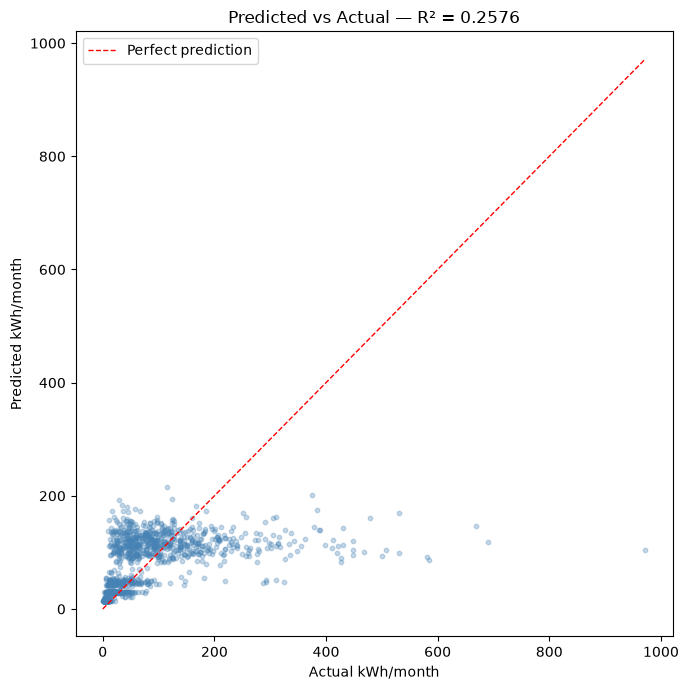

In [9]:
# Scatter plot: Predicted vs Actual
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, pred, alpha=0.3, s=10, color='steelblue')
lim = max(y_test.max(), pred.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual kWh/month')
ax.set_ylabel('Predicted kWh/month')
ax.set_title(f'Predicted vs Actual — R² = {r2:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

## 5. SHAP — Giải thích model

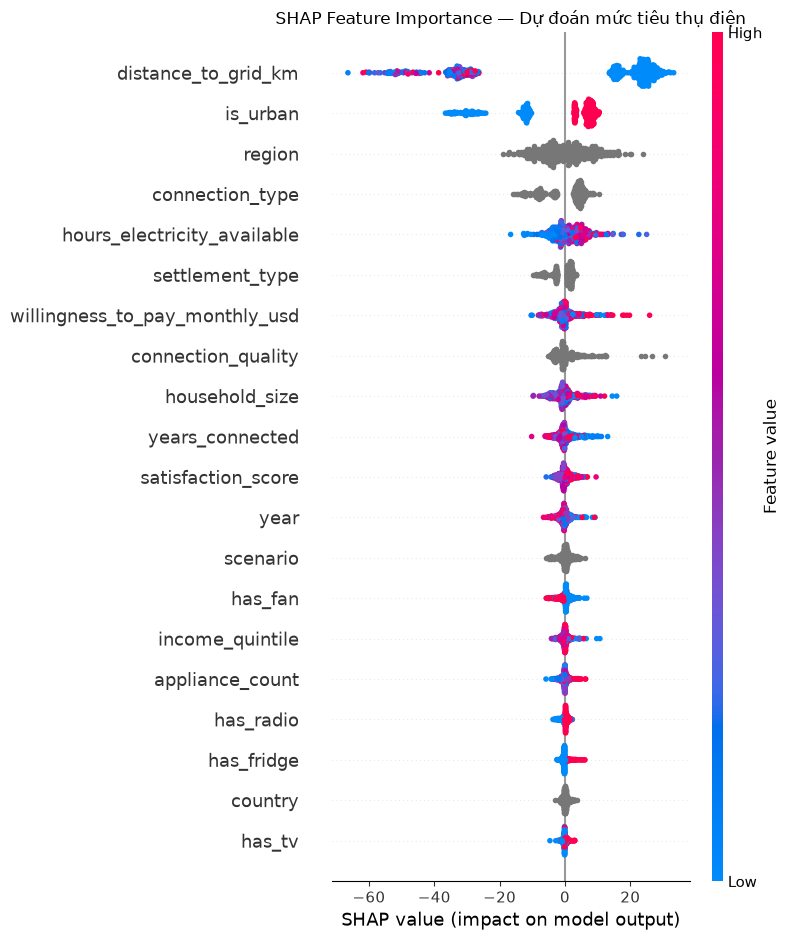

→ Lưu ý: điểm đỏ = giá trị feature cao, xanh = thấp; trục X = tác động lên dự đoán


In [10]:
explainer = shap.TreeExplainer(model)

# Lấy mẫu 500 dòng để vẽ nhanh
X_sample = X_test.sample(n=min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot: feature importance theo SHAP
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Feature Importance — Dự đoán mức tiêu thụ điện')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Lưu ý: điểm đỏ = giá trị feature cao, xanh = thấp; trục X = tác động lên dự đoán")

Hộ #0: actual = 52.8 kWh, predicted = 57.3 kWh
Thông tin hộ:
{'country': 'Tanzania', 'region': 'Tanzania_rural_dispersed_rural', 'is_urban': 0, 'settlement_type': 'dispersed_rural', 'household_size': 6, 'income_quintile': 5, 'education_head': 'secondary', 'connection_type': 'grid_direct', 'connection_quality': 'intermittent', 'years_connected': 0, 'hours_electricity_available': 17.299999237060547, 'distance_to_grid_km': 0.0, 'appliance_count': 4, 'has_phone_charging': 1, 'has_radio': 1, 'has_tv': 1, 'has_fridge': 0, 'has_fan': 0, 'has_electric_iron': 1, 'has_electric_kettle': 1, 'satisfaction_score': 6, 'willingness_to_pay_monthly_usd': 12.350000381469727, 'primary_cooking_fuel': 'electric', 'uses_multiple_sources': 1, 'has_backup_source': 0, 'barrier_count': 0, 'scenario': 'moderate_burden', 'year': 2019}


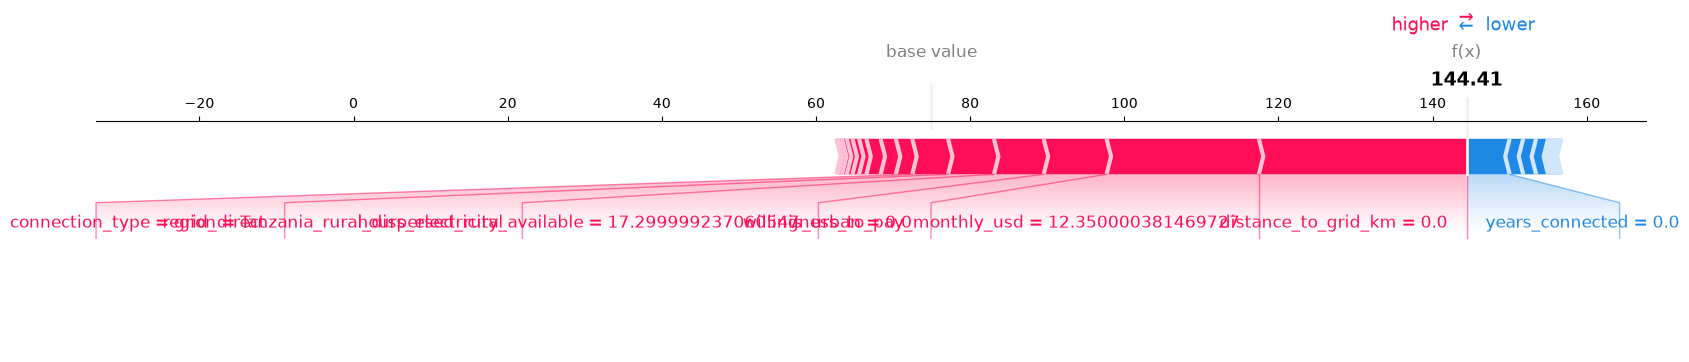

<Figure size 640x480 with 0 Axes>

In [11]:
# Force plot: giải thích dự đoán cho 1 hộ cụ thể (dùng trong báo cáo)
idx = 0  # hộ đầu tiên trong test set
print(f"Hộ #{idx}: actual = {y_test.iloc[idx]:.1f} kWh, predicted = {pred[idx]:.1f} kWh")
print("Thông tin hộ:")
print(X_test.iloc[idx].to_dict())

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test.iloc[idx],
    matplotlib=True
)
plt.savefig('shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Export kết quả về MotherDuck

In [12]:
# Tạo DataFrame kết quả
results_df = X_test.copy()
results_df['actual_kwh']    = y_test.values
results_df['predicted_kwh'] = pred.round(2)
results_df['error_kwh']     = (pred - y_test.values).round(2)
results_df['abs_error_kwh'] = np.abs(pred - y_test.values).round(2)

# Chuyển category về string để DuckDB nhận
for c in results_df.select_dtypes(include='category').columns:
    results_df[c] = results_df[c].astype(str)

# Upload lên MotherDuck
con.register('_pred_staging', results_df)
con.execute("CREATE SCHEMA IF NOT EXISTS gold;")
con.execute("""
    CREATE OR REPLACE TABLE gold.gold_predictions AS
    SELECT * FROM _pred_staging;
""")

n = con.execute("SELECT count(*) FROM gold.gold_predictions").fetchone()[0]
print(f"[OK] Export xong: {n:,} dòng trong gold.gold_predictions")
con.close()

[OK] Export xong: 1,239 dòng trong gold.gold_predictions


In [13]:
# Lưu model local (optional)
import joblib
joblib.dump(model, 'lgbm_kwh_model.pkl')
print("Model lưu tại lgbm_kwh_model.pkl")

Model lưu tại lgbm_kwh_model.pkl
